In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import ascii

# Read in some GPI spectra from NASA Exoplanet Archive

In [2]:
# read in spectra from NASA Exoplanet Archive
file_name_51_Eri_b_GPI = './data/51_Eri_b_3.11801_3607_3.tbl'
file_name_HD_143811_b_GPI = './data/HD_143811_b_3.20499_5857_1.tbl'
file_name_HR_8799_c_GPI = './data/HR_8799_c_3.11391_5636_1.tbl'
file_name_HR_8799_d_GPI = './data/HR_8799_d_3.11392_5636_1.tbl'
file_name_HR_8799_e_GPI = './data/HR_8799_e_3.11393_5636_1.tbl'

In [3]:
# read IPAC-formatted table using astropy, then convert to pandas
df_51_Eri_b_GPI = ascii.read(file_name_51_Eri_b_GPI, format='ipac').to_pandas()
df_HD_143811_b_GPI = ascii.read(file_name_HD_143811_b_GPI, format='ipac').to_pandas()
df_HR_8799_c_GPI = ascii.read(file_name_HR_8799_c_GPI, format='ipac').to_pandas()
df_HR_8799_d_GPI = ascii.read(file_name_HR_8799_d_GPI, format='ipac').to_pandas()
df_HR_8799_e_GPI = ascii.read(file_name_HR_8799_e_GPI, format='ipac').to_pandas()

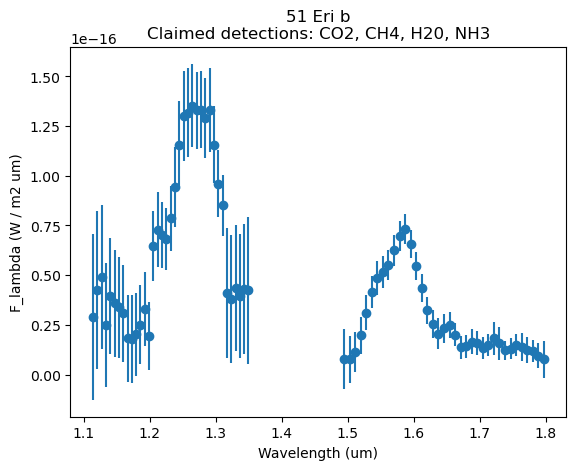

In [ ]:
plt.clf()
plt.errorbar(df_51_eri_b_GPI['CENTRALWAVELNG'], df_51_eri_b_GPI['FLAM'], yerr=df_51_eri_b_GPI['FLAMERR1'], fmt='o')
plt.xlabel('Wavelength (um)')
plt.ylabel('F_lambda (W / m2 um)')
plt.title('51 Eri b\nClaimed detections: CO2, CH4, H20, NH3')
plt.show()

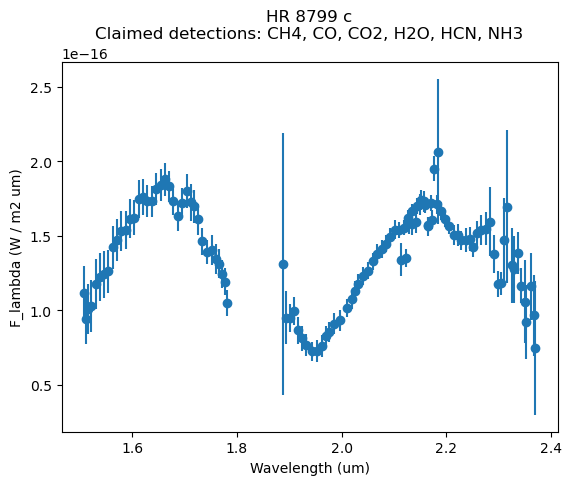

In [ ]:
plt.clf()
plt.errorbar(df_HR_8799_c_GPI['CENTRALWAVELNG'], df_HR_8799_c_GPI['FLAM'], yerr=df_HR_8799_c_GPI['FLAMERR1'], fmt='o')
plt.xlabel('Wavelength (um)')
plt.ylabel('F_lambda (W / m2 um)')
plt.title('HR 8799 c\nClaimed detections: CH4, CO, CO2, H2O, HCN, NH3')
plt.show()

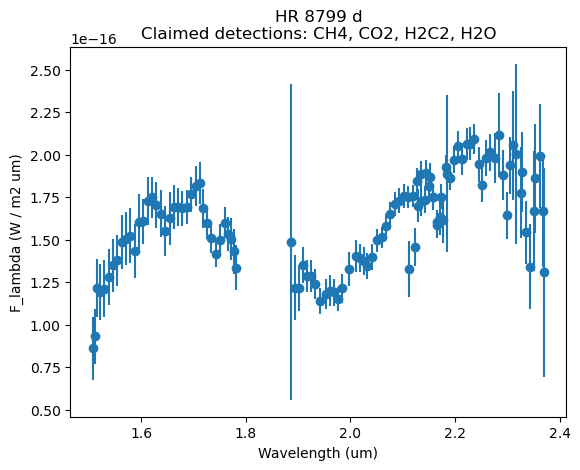

In [ ]:
plt.clf()
plt.errorbar(df_HR_8799_d_GPI['CENTRALWAVELNG'], df_HR_8799_d_GPI['FLAM'], yerr=df_HR_8799_d_GPI['FLAMERR1'], fmt='o')
plt.xlabel('Wavelength (um)')
plt.ylabel('F_lambda (W / m2 um)')
plt.title('HR 8799 d\nClaimed detections: CH4, CO2, H2C2, H2O')
plt.show()

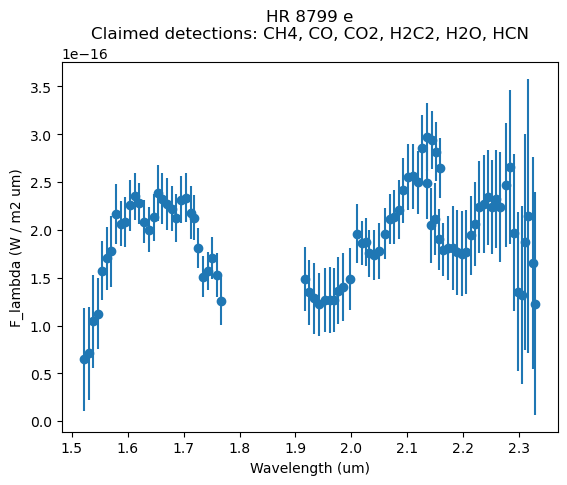

In [ ]:
plt.clf()
plt.errorbar(df_HR_8799_e_GPI['CENTRALWAVELNG'], df_HR_8799_e_GPI['FLAM'], yerr=df_HR_8799_e_GPI['FLAMERR1'], fmt='o')
plt.xlabel('Wavelength (um)')
plt.ylabel('F_lambda (W / m2 um)')
plt.title('HR 8799 e\nClaimed detections: CH4, CO, CO2, H2C2, H2O, HCN')
plt.show()

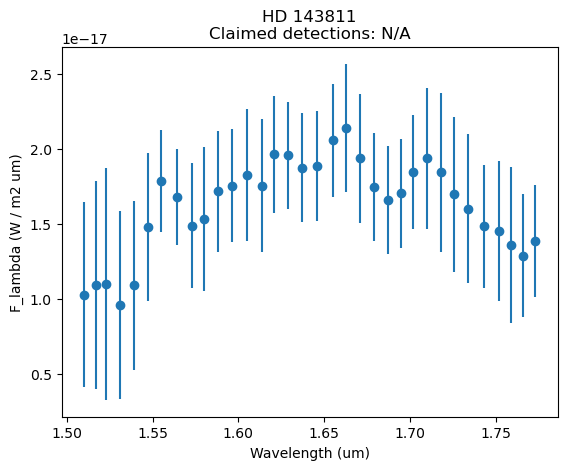

In [ ]:
plt.clf()
plt.errorbar(df_HD_143811_b_GPI['CENTRALWAVELNG'], df_HD_143811_b_GPI['FLAM'], yerr=df_HD_143811_b_GPI['FLAMERR1'], fmt='o')
plt.xlabel('Wavelength (um)')
plt.ylabel('F_lambda (W / m2 um)')
plt.title('HD 143811\nClaimed detections: N/A')
plt.show()

# Take a VLT/SPHERE data cube of HR 8799 and 'extract' spectra at resolution similar to GPI

In [ ]:
file_name_cube = './data/HIP_114189_DC_id_145619.fits'

In [ ]:
# read in FITS file

hdul = fits.open(file_name_cube)

#data_cube = hdul[0].data

In [ ]:
hdul.info()

Filename: ./data/HIP_114189_DC_id_145619.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     129   ()      
  1  DATA_INFORMATION    1 BinTableHDU     55   39R x 18C   [I, D, D, I, D, D, D, 160A, 160A, D, D, 160A, D, D, D, D, D, D]   
  2  REDUCED_DATA    1 ImageHDU      1189   (290, 290, 39)   float32   
  3  SNR_MAP       1 ImageHDU         7   ()      
  4  SENSITIVITY_MAP    1 ImageHDU         7   ()      
  5  DETECTION_LIMIT    1 BinTableHDU     14   39R x 2C   [205D, 205D]   
  6  SOURCE_DETECTION    1 BinTableHDU     90   0R x 22C   [I, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 39D, 1A, 1A]   


In [ ]:
data_cube = hdul[2].data

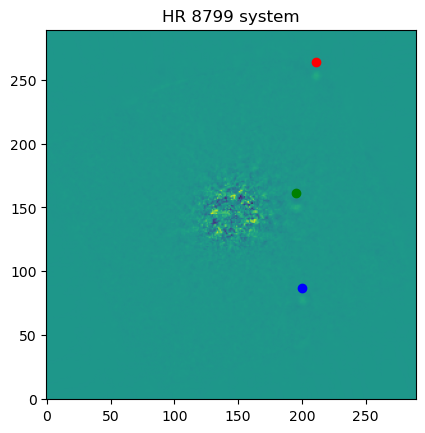

In [ ]:
plt.imshow(data_cube[33,:,:], origin='lower')
plt.scatter(211, 254+10, color='red')
plt.scatter(200, 77+10, color='blue')
plt.scatter(195, 151+10, color='green')
plt.title('HR 8799 system')
plt.show()

In [ ]:
wavel_um_abcissa = np.linspace(0.9575, 1.6358, len(data_cube[:,0,0]))

In [ ]:
del_R = 2 * np.median(wavel_um_abcissa-np.roll(wavel_um_abcissa,1))

print(f'Spectral resolution: {wavel_um_abcissa[0]/del_R:.1f} to {wavel_um_abcissa[-1]/del_R:.1f}')

Spectral resolution: 26.8 to 45.8


In [ ]:
flux_planet_c = data_cube[:,254,211]
flux_planet_d = data_cube[:,77,200]
flux_planet_e = data_cube[:,151,195]

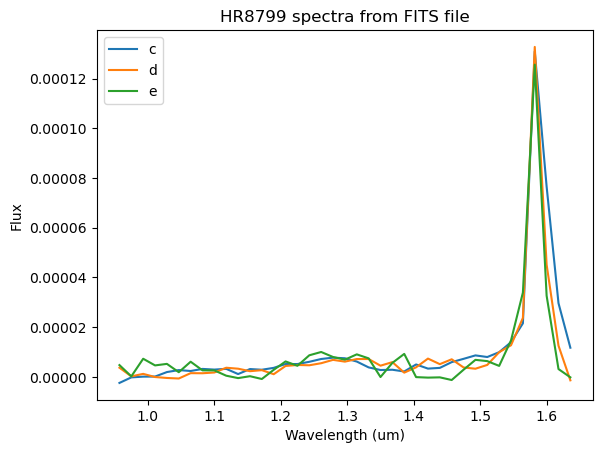

In [ ]:
plt.plot(wavel_um_abcissa, flux_planet_c, label='c')
plt.plot(wavel_um_abcissa, flux_planet_d, label='d')
plt.plot(wavel_um_abcissa, flux_planet_e, label='e')
plt.xlabel('Wavelength (um)')
plt.ylabel('Flux')
plt.title('HR8799 spectra from FITS file')
plt.legend()
plt.show()